# Cohort creation Notebook

## Dependencies and Setup

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import tools.helpers as hh
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from venn import venn

In [2]:
user = "postgres"
password = "mimic"
host = "localhost"   
port = "5432"
database = "mimiciv"

In [3]:
engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")


# Load data 


## main cohort

In [4]:
df_resp_inf_icu_final = pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/parq/df_resp_inf_icu_final.parq", engine="fastparquet")
df_resp_inf_icu_hadm_ids = tuple(df_resp_inf_icu_final.hadm_id.unique().tolist())
df_resp_inf_icu_subject_ids = tuple(df_resp_inf_icu_final.subject_id.unique().tolist())


In [15]:
all_adm_df= hh.load_data('./parq/all_adm_df_27Feb26_1738.parquet')
hh.dxx(all_adm_df)

11.9k Unique Patient IDs (11905)
59.0k Unique Admission IDs (59024)
24.5k Unique ICU Stay IDs (24504)
62.7k Rows, shape: (62657, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],float64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,4304 | 58353,24504 | 38153,24504 | 38153,24495 | 38162,24495 | 38162,62657 | 0,62657 | 0,53655 | 9002,62657 | 0
nunique,11905,2,73,96,59024,58945,58790,3424,24505,24504,24496,24019,9,11,14,33
0,10006508,F,71,2132,20850343,2132-03-28 22:38:00,2132-04-02 15:00:00,NaT,nan,NaT,NaT,nan,OBSERVATION ADMIT,EMERGENCY ROOM,HOME HEALTH CARE,BLACK/AFRICAN AMERICAN
1,10001843,M,73,2131,21728396,2131-11-09 16:05:00,2131-11-11 11:23:00,NaT,nan,NaT,NaT,nan,OBSERVATION ADMIT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE
2,10001843,M,73,2131,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,39698942.000000,2134-12-05 18:50:03,2134-12-06 14:38:26,0.825266,URGENT,TRANSFER FROM HOSPITAL,DIED,WHITE


In [16]:
all_hadm_ids = tuple(all_adm_df.hadm_id.unique().tolist())


In [14]:
len(df_resp_inf_icu_hadm_ids)

13611

In [13]:
len(df_resp_inf_icu_subject_ids)

11905

In [5]:
df_admissions = pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/parq/df_admissions.parq", engine="fastparquet")    
hh.dxx(df_admissions)


11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
16.4k Rows, shape: (16438, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,3620 | 12818,16438 | 0,16438 | 0,16429 | 9,16429 | 9,16438 | 0,16438 | 0,16405 | 33,16438 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN


In [7]:
rep_inf_cohort= df_admissions.merge(df_resp_inf_icu_final, on=["hadm_id", "subject_id","stay_id"], how="inner")
hh.dxx(rep_inf_cohort)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


In [8]:
resp_inf_cohort= hh.load_data('./parq/resp_inf_cohort_23Jan26_1953.parquet')
hh.dxx(resp_inf_cohort)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


In [ ]:
query = f"""
-- Get respiratory infection ICU patients with any microbiology record during ICU stay (raw data)
SELECT 
    icu.subject_id,
    icu.hadm_id,
    icu.stay_id,
    icu.first_careunit,
    icu.last_careunit,
    icu.intime,
    icu.outtime,
    icu.los,
    me.microevent_id,
    me.chartdate,
    me.charttime,
    me.spec_type_desc,
    me.test_name,
    me.org_name,
    me.ab_name,
    me.interpretation,
    me.dilution_value,
    me.comments
FROM mimiciv_icu.icustays icu
INNER JOIN mimiciv_hosp.microbiologyevents me 
    ON icu.subject_id = me.subject_id 
    AND icu.hadm_id = me.hadm_id
WHERE icu.hadm_id IN {df_resp_inf_icu_hadm_ids}
     AND icu.hadm_id IS NOT NULL 
;



"""


resp_micro_hosp_icu_inf_df = pd.read_sql_query(query, con=engine)

In [ ]:
hh.dxx(resp_micro_hosp_icu_inf_df)

11.3k Unique Patient IDs (11348)
12.9k Unique Admission IDs (12922)
15.7k Unique ICU Stay IDs (15723)
421.7k Rows, shape: (421739, 18)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object
NotNA | NA,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,156805 | 264934,127899 | 293840,127899 | 293840,121517 | 300222,356177 | 65562
nunique,11348,12922,15723,14,14,15723,15723,15561,289021,28540,121843,72,128,312,47,6,26,264
0,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5128,2133-09-17 00:00:00,2133-09-17 13:05:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,nan,NO GROWTH.
1,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5139,2133-10-01 00:00:00,2133-10-01 23:17:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,nan,NO GROWTH.
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,GRAM STAIN,None,None,None,nan,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICROORGANISMS SEEN.


In [ ]:
# hh.parq(resp_micro_hosp_icu_inf_df,'resp_micro_hosp_icu_inf_df_')

In [27]:
resp_micro_hosp_icu_inf_df=hh.load_data('./parq/resp_micro_hosp_icu_inf_df_23Jan26_2050.parquet')
hh.dxx(resp_micro_hosp_icu_inf_df)

11.3k Unique Patient IDs (11348)
12.9k Unique Admission IDs (12922)
15.7k Unique ICU Stay IDs (15723)
421.7k Rows, shape: (421739, 18)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object
NotNA | NA,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,421739 | 0,156805 | 264934,127899 | 293840,127899 | 293840,121517 | 300222,356177 | 65562
nunique,11348,12922,15723,14,14,15723,15723,15561,289021,28540,121843,72,128,312,47,6,26,264
0,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5128,2133-09-17 00:00:00,2133-09-17 13:05:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,nan,NO GROWTH.
1,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5139,2133-10-01 00:00:00,2133-10-01 23:17:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,nan,NO GROWTH.
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,GRAM STAIN,None,None,None,nan,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICROORGANISMS SEEN.


In [ ]:
query = f"""
SELECT
    icu.subject_id, icu.hadm_id, icu.stay_id, icu.first_careunit, icu.last_careunit,
    icu.intime, icu.outtime, icu.los,
    le.labevent_id, le.specimen_id, le.itemid,
    dli.label, dli.fluid, dli.category,
    le.charttime, le.storetime, le.value, le.valuenum, le.valueuom,
    le.ref_range_lower, le.ref_range_upper, le.flag, le.priority, le.comments
FROM mimiciv_icu.icustays icu
INNER JOIN mimiciv_hosp.labevents le
  ON icu.subject_id = le.subject_id
  AND icu.hadm_id   = le.hadm_id
  
LEFT JOIN mimiciv_hosp.d_labitems dli
  ON le.itemid = dli.itemid
WHERE icu.hadm_id IN {df_resp_inf_icu_hadm_ids}
  AND icu.hadm_id IS NOT NULL
  AND le.charttime IS NOT NULL
"""
lab_test_hosp_icu_df = pd.read_sql_query(query, con=engine)


In [ ]:
# hh.parq(lab_test_hosp_icu_df,'lab_test_hosp_icu_df_')

File saved at: lab_test_hosp_icu_df_23Jan26_2125.parquet


In [26]:
lab_test_hosp_icu_df= hh.load_data('./parq/lab_test_hosp_icu_df_23Jan26_2125.parquet')
hh.dxx(lab_test_hosp_icu_df)

11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
16.4k Unique ICU Stay IDs (16370)
16.2M Rows, shape: (16160654, 24)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,int64,int64,object,object,object,datetime64[ns],datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16159695 | 959,16159695 | 959,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16102997 | 57657,15288675 | 871979,14732259 | 1428395,13899108 | 2261546,13207329 | 2953325,13207329 | 2953325,6803607 | 9357047,13562976 | 2597678,2393141 | 13767513
nunique,11864,13549,16370,14,14,16370,16367,16185,10886372,1158463,848,688,9,3,682239,1601059,15045,18070,57,118,170,2,3,5100
0,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,265253,73252082,50802,Base Excess,Blood,Blood Gas,2177-02-15 19:55:00,2177-02-15 20:20:00,-4,-4.000000,mEq/L,nan,nan,None,None,None
1,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,265573,2360138,50947,I,Blood,Chemistry,2177-02-23 06:16:00,2177-02-23 08:20:00,1,1.000000,None,nan,nan,None,ROUTINE,None
2,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264734,15757621,50868,Anion Gap,Blood,Chemistry,2177-02-06 20:43:00,2177-02-06 23:27:00,11,11.000000,mEq/L,10.000000,18.000000,None,STAT,None


In [38]:
query = f"""SELECT table_schema, table_name
FROM information_schema.tables
;"""

df = pd.read_sql_query(query, con=engine)

In [40]:
df.table_schema.unique()

array(['mimiciv_hosp', 'pg_catalog', 'mimiciv_icu', 'information_schema'],
      dtype=object)

In [43]:
query = f"""
SELECT
    c.subject_id,
    c.hadm_id,
    a.admittime,
    c.charlson_comorbidity_index

FROM mimiciv_derived.charlson c

JOIN mimiciv_hosp.admissions a
    ON c.hadm_id = a.hadm_id

WHERE c.subject_id IN {df_resp_inf_icu_subject_ids}
;
"""

comorb_df = pd.read_sql_query(query, con=engine)

In [45]:
hh.parq(comorb_df,'comorb_df_')

File saved at: comorb_df_03Mar26_1553.parquet


In [47]:
comorb_df=hh.load_data('./parq/comorb_df_03Mar26_1553.parquet')

In [10]:
query = f"""

SELECT
  em.subject_id,
  em.hadm_id,
  icu.stay_id,
  icu.first_careunit,
  icu.last_careunit,
  icu.intime  AS icu_intime,
  icu.outtime AS icu_outtime,
  em.emar_id,
  em.emar_seq,
  em.charttime,
  em.medication,
  ed.parent_field_ordinal,
  ed.administration_type,
  ed.dose_due,
  ed.dose_due_unit,
  ed.dose_given,
  ed.dose_given_unit,
  ed.product_code,
  ed.product_description
FROM mimiciv_hosp.emar em
JOIN mimiciv_hosp.emar_detail ed
  ON em.subject_id = ed.subject_id
 AND em.emar_id    = ed.emar_id
 AND em.emar_seq   = ed.emar_seq

-- JOIN mimiciv_icu.icustays icu
  --ON icu.subject_id = em.subject_id
 --AND icu.hadm_id    = em.hadm_id
 
WHERE em.subject_id IS NOT NULL
  AND em.subject_id IN {df_resp_inf_icu_subject_ids}
;
"""

all_emar_hosp_icu_inf_results_df = pd.read_sql_query(query, con=engine)

IOStream.flush timed out


In [24]:
import pandas as pd

def fetch_emar_in_batches(subject_ids, engine, batch_size=500, verbose=True):
    """
    Fetch EMAR data in controlled batches.
    
    Parameters:
    - subject_ids : iterable (list/tuple/array)
    - engine      : SQLAlchemy engine
    - batch_size  : number of subject_ids per batch
    - verbose     : print progress
    
    Returns:
    - concatenated pandas DataFrame
    """
    
    subject_ids = list(subject_ids)  # make robust
    all_results = []
    
    total = len(subject_ids)
    
    for i in range(0, total, batch_size):
        
        batch = subject_ids[i:i + batch_size]
        batch_tuple = tuple(batch)
        
        if verbose:
            print(f"Processing batch {i//batch_size + 1} | "
                  f"Records {i} to {min(i+batch_size, total)}")
        
        query = f"""
        SELECT
            em.subject_id,
            em.hadm_id,
       
            em.emar_id,
            em.emar_seq,
            em.charttime,
            em.medication

        FROM mimiciv_hosp.emar em



        WHERE em.subject_id IN {batch_tuple}
        ;
        """
        
        df_batch = pd.read_sql_query(query, con=engine)
        all_results.append(df_batch)
    
    return pd.concat(all_results, ignore_index=True)

In [28]:
import pandas as pd

def fetch_emar_in_batches(subject_ids, engine, batch_size=500, verbose=True):
    """
    Fetch EMAR data in batches and attach stay_id (no time filtering).
    """
    
    subject_ids = list(subject_ids)
    all_results = []
    total = len(subject_ids)
    
    for i in range(0, total, batch_size):
        
        batch = subject_ids[i:i + batch_size]
        batch_tuple = tuple(batch)
        
        if verbose:
            print(f"Processing batch {i//batch_size + 1} | "
                  f"Records {i} to {min(i+batch_size, total)}")
        
        query = f"""
        SELECT
            em.subject_id,
            em.hadm_id,
            icu.stay_id,
            em.emar_id,
            em.emar_seq,
            em.charttime,
            em.medication

        FROM mimiciv_hosp.emar em

        LEFT JOIN mimiciv_icu.icustays icu
            ON em.hadm_id = icu.hadm_id

        WHERE em.subject_id IN {batch_tuple}
        ;
        """
        
        df_batch = pd.read_sql_query(query, con=engine)
        all_results.append(df_batch)
    
    return pd.concat(all_results, ignore_index=True)

In [ ]:
import pandas as pd

def fetch_emar_in_batches(subject_ids, engine, batch_size=500, verbose=True):
    """
    Fetch EMAR data in batches and attach stay_id + product metadata.
    """
    
    subject_ids = list(subject_ids)
    all_results = []
    total = len(subject_ids)
    
    for i in range(0, total, batch_size):
        
        batch = subject_ids[i:i + batch_size]
        batch_tuple = tuple(batch)
        
        if verbose:
            print(f"Processing batch {i//batch_size + 1} | "
                  f"Records {i} to {min(i+batch_size, total)}")
        
        query = f"""
        SELECT
            em.subject_id,
            em.hadm_id,
            icu.stay_id,
            em.emar_id,
            em.emar_seq,
            em.charttime,
            em.medication,
            ed.product_code,
            ed.product_description

        FROM mimiciv_hosp.emar em

        LEFT JOIN mimiciv_hosp.emar_detail ed
            ON em.subject_id = ed.subject_id
           AND em.emar_id    = ed.emar_id
           AND em.emar_seq   = ed.emar_seq

        LEFT JOIN mimiciv_icu.icustays icu
            ON em.hadm_id = icu.hadm_id

        WHERE em.subject_id IN {batch_tuple}
        ;
        """
        
        df_batch = pd.read_sql_query(query, con=engine)
        all_results.append(df_batch)
    
    return pd.concat(all_results, ignore_index=True)

In [29]:
all_emar_hosp_icu_inf_results_df = fetch_emar_in_batches(
    df_resp_inf_icu_subject_ids,
    engine,
    batch_size=1000  
)

Processing batch 1 | Records 0 to 1000
Processing batch 2 | Records 1000 to 2000
Processing batch 3 | Records 2000 to 3000
Processing batch 4 | Records 3000 to 4000
Processing batch 5 | Records 4000 to 5000
Processing batch 6 | Records 5000 to 6000
Processing batch 7 | Records 6000 to 7000
Processing batch 8 | Records 7000 to 8000
Processing batch 9 | Records 8000 to 9000
Processing batch 10 | Records 9000 to 10000
Processing batch 11 | Records 10000 to 11000
Processing batch 12 | Records 11000 to 11905


In [30]:
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
14.8k Unique ICU Stay IDs (14819)
13.2M Rows, shape: (13223571, 7)



In [9]:
import pandas as pd

def fetch_emar_in_batches(subject_ids, engine, batch_size=500, verbose=True):
    """
    Fetch EMAR data in controlled batches.
    
    Parameters:
    - subject_ids : iterable (list/tuple/array)
    - engine      : SQLAlchemy engine
    - batch_size  : number of subject_ids per batch
    - verbose     : print progress
    
    Returns:
    - concatenated pandas DataFrame
    """
    
    subject_ids = list(subject_ids)  # make robust
    all_results = []
    
    total = len(subject_ids)
    
    for i in range(0, total, batch_size):
        
        batch = subject_ids[i:i + batch_size]
        batch_tuple = tuple(batch)
        
        if verbose:
            print(f"Processing batch {i//batch_size + 1} | "
                  f"Records {i} to {min(i+batch_size, total)}")
        
        query = f"""
        SELECT
            em.subject_id,
            em.hadm_id,
            icu.stay_id,
            em.emar_id,
            em.emar_seq,
            em.charttime,
            em.medication,
            ed.parent_field_ordinal,
            ed.administration_type,
            ed.dose_due,
            ed.dose_due_unit,
            ed.dose_given,
            ed.dose_given_unit,
            ed.product_code,
            ed.product_description

        FROM mimiciv_hosp.emar em

        LEFT JOIN mimiciv_hosp.emar_detail ed
            ON em.subject_id = ed.subject_id
           AND em.emar_id    = ed.emar_id
           AND em.emar_seq   = ed.emar_seq

        LEFT JOIN mimiciv_icu.icustays icu
            ON em.hadm_id = icu.hadm_id
          
        WHERE em.hadm_id IN {batch_tuple}
        ;
        """
        
        df_batch = pd.read_sql_query(query, con=engine)
        all_results.append(df_batch)
    
    return pd.concat(all_results, ignore_index=True)

In [20]:
all_emar_adm_results_df = fetch_emar_in_batches(all_hadm_ids,engine,batch_size=500)

Processing batch 1 | Records 0 to 500
Processing batch 2 | Records 500 to 1000
Processing batch 3 | Records 1000 to 1500
Processing batch 4 | Records 1500 to 2000
Processing batch 5 | Records 2000 to 2500
Processing batch 6 | Records 2500 to 3000
Processing batch 7 | Records 3000 to 3500
Processing batch 8 | Records 3500 to 4000
Processing batch 9 | Records 4000 to 4500
Processing batch 10 | Records 4500 to 5000
Processing batch 11 | Records 5000 to 5500
Processing batch 12 | Records 5500 to 6000
Processing batch 13 | Records 6000 to 6500
Processing batch 14 | Records 6500 to 7000
Processing batch 15 | Records 7000 to 7500
Processing batch 16 | Records 7500 to 8000
Processing batch 17 | Records 8000 to 8500
Processing batch 18 | Records 8500 to 9000
Processing batch 19 | Records 9000 to 9500
Processing batch 20 | Records 9500 to 10000
Processing batch 21 | Records 10000 to 10500
Processing batch 22 | Records 10500 to 11000
Processing batch 23 | Records 11000 to 11500
Processing batch 2

KeyboardInterrupt: 

In [10]:
all_emar_hosp_icu_inf_results_df = fetch_emar_in_batches(
    df_resp_inf_icu_subject_ids,
    engine,
    batch_size=500  
)

Processing batch 1 | Records 0 to 500
Processing batch 2 | Records 500 to 1000
Processing batch 3 | Records 1000 to 1500
Processing batch 4 | Records 1500 to 2000
Processing batch 5 | Records 2000 to 2500
Processing batch 6 | Records 2500 to 3000
Processing batch 7 | Records 3000 to 3500
Processing batch 8 | Records 3500 to 4000
Processing batch 9 | Records 4000 to 4500
Processing batch 10 | Records 4500 to 5000
Processing batch 11 | Records 5000 to 5500
Processing batch 12 | Records 5500 to 6000
Processing batch 13 | Records 6000 to 6500
Processing batch 14 | Records 6500 to 7000
Processing batch 15 | Records 7000 to 7500
Processing batch 16 | Records 7500 to 8000
Processing batch 17 | Records 8000 to 8500
Processing batch 18 | Records 8500 to 9000
Processing batch 19 | Records 9000 to 9500
Processing batch 20 | Records 9500 to 10000
Processing batch 21 | Records 10000 to 10500
Processing batch 22 | Records 10500 to 11000
Processing batch 23 | Records 11000 to 11500
Processing batch 2

In [ ]:
hh.parq(all_emar_adm_results_df,'all_emar_adm_results_df')


In [31]:
hh.parq(all_emar_hosp_icu_inf_results_df,'all_emar_hosp_icu_inf_results_df_')

File saved at: all_emar_hosp_icu_inf_results_df_03Mar26_0232.parquet


In [12]:
# hh.parq(resp_emar_hosp_icu_inf_results_df,'resp_emar_hosp_icu_inf_results_df_')

File saved at: resp_emar_hosp_icu_inf_results_df_24Jan26_0507.parquet


In [32]:
all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_03Mar26_0232.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
14.8k Unique ICU Stay IDs (14819)
13.2M Rows, shape: (13223571, 7)



In [18]:
# all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_02Mar26_0412.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
ICU Stay ID column not found.
19.7M Rows, shape: (19659089, 14)



In [20]:
all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_02Mar26_0412.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

7.8k Unique Patient IDs (7805)
12.3k Unique Admission IDs (12346)
14.8k Unique ICU Stay IDs (14819)
20.1M Rows, shape: (20116164, 19)



In [13]:
resp_emar_hosp_icu_inf_results_df=hh.load_data('./parq/resp_emar_hosp_icu_inf_results_df_24Jan26_0507.parquet')
hh.dx(resp_emar_hosp_icu_inf_results_df)

7.5k Unique Patient IDs (7511)
8.4k Unique Admission IDs (8356)
10.3k Unique ICU Stay IDs (10324)
15.9M Rows, shape: (15923208, 19)



In [24]:
#inputevents from ICU - Results specific to ICU patients with respiratory infections, INPUT EVENTS NOT AVAILABLE IN HOSPITAL MODULE
resp_inputevents_icu_inf_results_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/parq/resp_inputevents_icu_inf_results_df.parquet")

In [ ]:
hh.dx(resp_emar_icu_inf_results_df)

6.7k Unique Patient IDs (6735)
7.4k Unique Admission IDs (7447)
9.1k Unique ICU Stay IDs (9143)
5.0M Rows, shape: (4980994, 19)



## PRESCRIPTIONS

In [19]:
query = f"""

SELECT 
    pr.subject_id,
    pr.hadm_id,
    icu.stay_id,
    icu.first_careunit,
    icu.last_careunit,
    icu.intime  AS icu_intime,
    icu.outtime AS icu_outtime,
    pr.pharmacy_id,
    pr.starttime,
    pr.stoptime,
    pr.drug_type,
    pr.drug,
    pr.formulary_drug_cd,
    pr.gsn,
    pr.ndc,
    pr.prod_strength,
    pr.form_rx,
    pr.dose_val_rx,
    pr.dose_unit_rx,
    pr.form_val_disp,
    pr.form_unit_disp,
    pr.doses_per_24_hrs,
    pr.route
FROM mimiciv_hosp.prescriptions pr
JOIN mimiciv_icu.icustays icu
  ON icu.subject_id = pr.subject_id
 AND icu.hadm_id    = pr.hadm_id

WHERE pr.hadm_id IS NOT NULL
  AND pr.hadm_id IN {df_resp_inf_icu_hadm_ids}
;
"""

resp_pres_hosp_icu_inf_results_df = pd.read_sql_query(query, con=engine)

In [ ]:
# hh.parq(resp_pres_hosp_icu_inf_results_df,'resp_pres_hosp_icu_inf_results_df')


File saved at: resp_pres_hosp_icu_inf_results_df24Jan26_0526.parquet


In [21]:
resp_pres_hosp_icu_inf_results_df=hh.load_data('./parq/resp_pres_hosp_icu_inf_results_df24Jan26_0526.parquet')
hh.dxx(resp_pres_hosp_icu_inf_results_df)

11.9k Unique Patient IDs (11870)
13.6k Unique Admission IDs (13570)
16.4k Unique ICU Stay IDs (16391)
2.9M Rows, shape: (2897824, 23)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,pharmacy_id,starttime,stoptime,drug_type,drug,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,float64,object
NotNA | NA,2897824 | 0,2897824 | 0,2897824 | 0,2897824 | 0,2897824 | 0,2897824 | 0,2896086 | 1738,2897824 | 0,2894673 | 3151,2892425 | 5399,2897824 | 0,2897824 | 0,2896603 | 1221,2433495 | 464329,2894610 | 3214,2895787 | 2037,587186 | 2310638,2895795 | 2029,2895795 | 2029,2895795 | 2029,2895794 | 2030,1748856 | 1148968,2895904 | 1920
nunique,11870,13570,16391,14,14,16391,16383,1609377,470120,404625,3,3069,2998,2677,5115,2414,45,1576,97,1914,77,13,83
0,10002155,20345487,32358465,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-03-09 21:33:00,2131-03-10 18:09:21,3244129,2131-03-10 02:00:00,2131-03-10 06:00:00,BASE,0.9% Sodium Chloride,NS1000,001210,00338004904,1000mL Bag,None,1000,mL,1,BAG,nan,IV
1,10007795,28477357,31921355,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2136-04-22 18:01:13,2136-04-23 19:13:58,487804,2136-04-22 19:00:00,2136-05-02 21:00:00,MAIN,Sodium Chloride 0.9% Flush,NACLFLUSH,None,0,Syringe,None,3,mL,0.6,SYR,3.000000,IV
2,10007795,28477357,31921355,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2136-04-22 18:01:13,2136-04-23 19:13:58,3024099,2136-04-21 03:00:00,2136-04-24 18:00:00,MAIN,Insulin,INSULIN,001723,0,Dummy Package for Sliding Scale,None,0,UNIT,0,VIAL,nan,SC


In [ ]:
# Ensure the five sets exist
required_sets = {
    'Micro': 'overall_micro_ids',
    'Prescriptions': 'overall_pres_ids',
    'EMAR': 'overall_emar_ids',
    'InputEvents': 'overall_input_ids',
    'Labs': 'overall_lab_ids',
}
missing = [name for name, var in required_sets.items() if var not in globals()]
if missing:
    raise NameError(f"Missing variables for sets: {missing}. Ensure overall_* sets are defined above.")

set_map = {
    'Micro': overall_micro_ids,
    'Prescriptions': overall_pres_ids,
    'EMAR': overall_emar_ids,
    'InputEvents': overall_input_ids,
    'Labs': overall_lab_ids,
}

print({k: len(v) for k, v in set_map.items()})
plt.figure(figsize=(9, 9))
venn(set_map)
plt.title('Overlap of HADM_IDs across 5 dataframes')
plt.tight_layout()

# os.makedirs('outputs', exist_ok=True)
# plt.savefig('outputs/hadm_ids_venn_5sets.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# pip install upsetplot


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24863 sha256=25000d0f1e74e23187087f7114feeab9894591196a12785d231d5068e09225bd
  Stored in directory: /Users/gnaanikko.pa/Library/Caches/pip/wheels/25/f7/e8/cf1a20f6721631b3607d04dfd5c31889cf5a512177fa2a0564
Successfully built upsetplot

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
pres_set = set(resp_pres_hosp_icu_inf_results_df['hadm_id'])
input_set = set(resp_inputevents_icu_inf_results_df['hadm_id'])
lab_set = set(lab_test_hosp_icu_df['hadm_id'])
micro_set = set(resp_micro_hosp_icu_inf_df['hadm_id'])
emar_set = set(resp_emar_hosp_icu_inf_results_df['hadm_id'])


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermedia

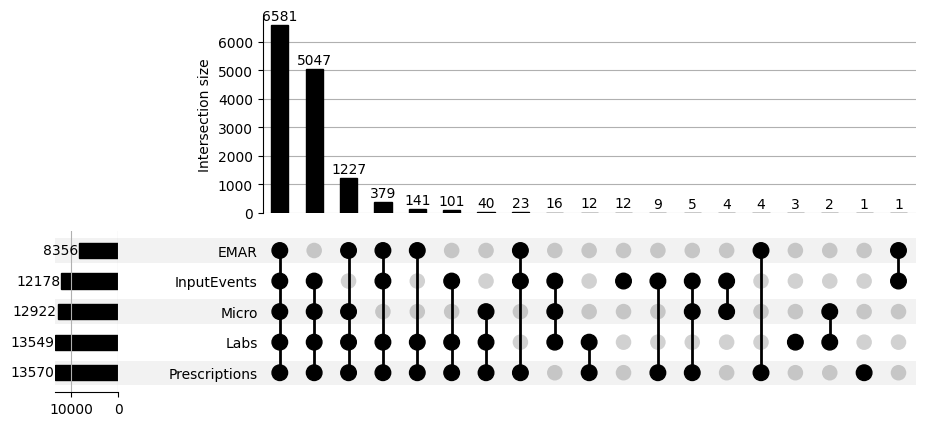

In [44]:
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt

data = from_contents({
    'Micro': micro_set,
    'Prescriptions': pres_set,
    'EMAR': emar_set,
    'InputEvents': input_set,
    'Labs': lab_set,
})

UpSet(
    data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality'
).plot()

plt.show()


{'Micro': 12922, 'Prescriptions': 13570, 'EMAR': 8356, 'InputEvents': 12178, 'Labs': 13549}


<Figure size 900x900 with 0 Axes>

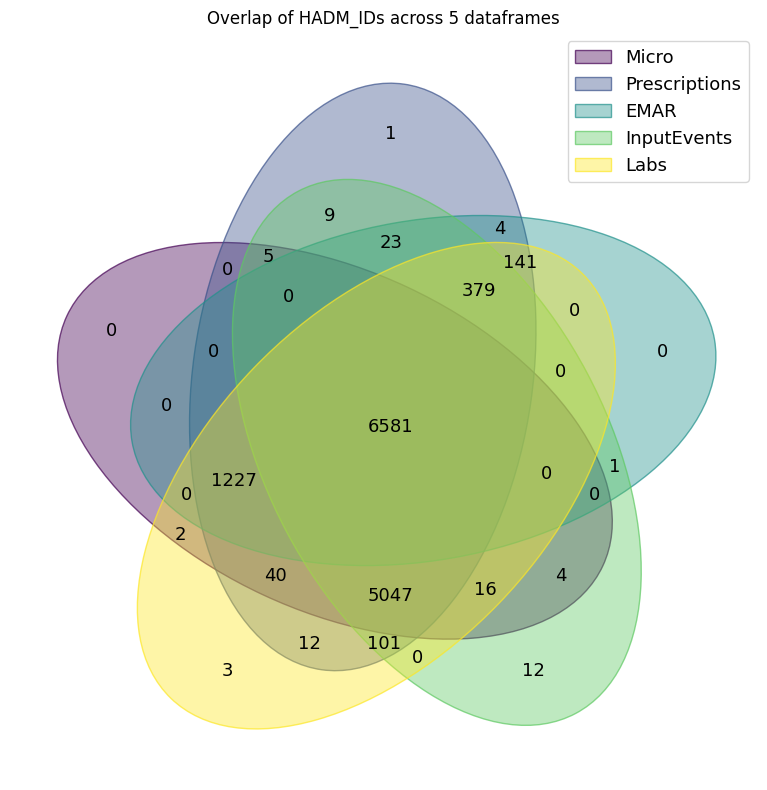

In [36]:

set_map = {
    'Micro': micro_set,
    'Prescriptions': pres_set,
    'EMAR': emar_set,
    'InputEvents': input_set,
    'Labs': lab_set,
}
print({k: len(v) for k, v in set_map.items()})
plt.figure(figsize=(9, 9))
venn(set_map)
plt.title('Overlap of HADM_IDs across 5 dataframes')
plt.tight_layout()
# os.makedirs('outputs', exist_ok=True)
# plt.savefig('outputs/hadm_ids_venn_5sets.png', dpi=200, bbox_inches='tight')
plt.show()

In [37]:
resp_micro_hosp_icu_inf_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments
0,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5128,2133-09-17,2133-09-17 13:05:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,NaN,NO GROWTH.
1,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5139,2133-10-01,2133-10-01 23:17:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,NaN,NO GROWTH.
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04,2135-01-04 13:41:00,PLEURAL FLUID,GRAM STAIN,None,None,None,NaN,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICR...
3,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5140,2133-10-01,2133-10-01 23:17:00,BLOOD CULTURE,"Blood Culture, Routine",None,None,None,NaN,NO GROWTH.
4,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5141,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,S,1.0,None


In [38]:
resp_micro_hosp_icu_inf_results_df= resp_micro_hosp_icu_inf_df.dropna(subset=['ab_name','interpretation','org_name'], how='all')

In [43]:
hh.dx(resp_micro_hosp_icu_inf_df)
hh.dx(resp_micro_hosp_icu_inf_results_df)

11.3k Unique Patient IDs (11348)
12.9k Unique Admission IDs (12922)
15.7k Unique ICU Stay IDs (15723)
421.7k Rows, shape: (421739, 18)

6.7k Unique Patient IDs (6698)
7.4k Unique Admission IDs (7370)
9.5k Unique ICU Stay IDs (9503)
156.8k Rows, shape: (156805, 18)



In [39]:
micro_results_set = set(resp_micro_hosp_icu_inf_results_df['hadm_id'])

{'Micro': 7370, 'Prescriptions': 13570, 'EMAR': 8356, 'InputEvents': 12178, 'Labs': 13549}


<Figure size 900x900 with 0 Axes>

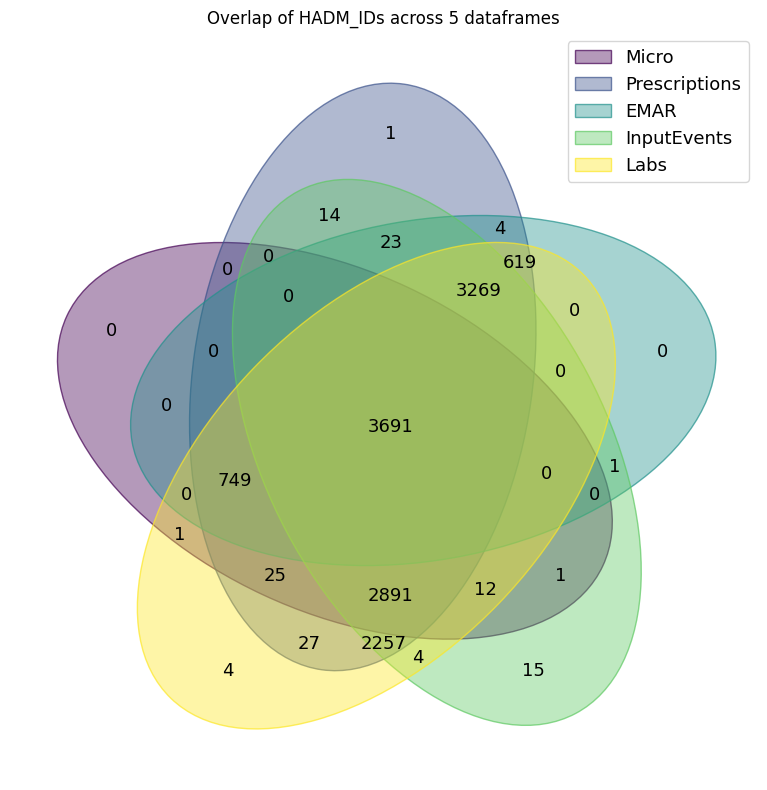

In [40]:

set_map = {
    'Micro': micro_results_set,
    'Prescriptions': pres_set,
    'EMAR': emar_set,
    'InputEvents': input_set,
    'Labs': lab_set,
}
print({k: len(v) for k, v in set_map.items()})
plt.figure(figsize=(9, 9))
venn(set_map)
plt.title('Overlap of HADM_IDs across 5 dataframes')
plt.tight_layout()
# os.makedirs('outputs', exist_ok=True)
# plt.savefig('outputs/hadm_ids_venn_5sets.png', dpi=200, bbox_inches='tight')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermedia

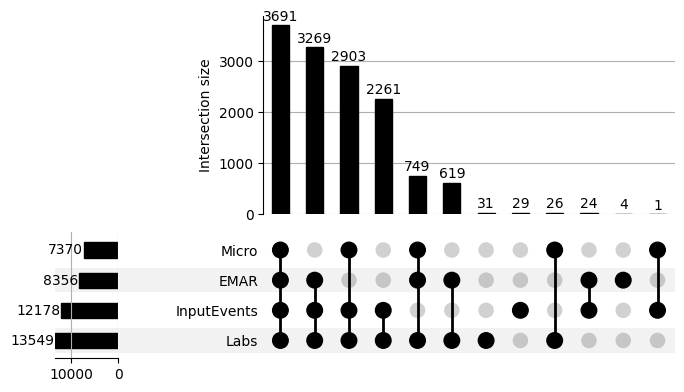

In [56]:
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt

data = from_contents({
    'Micro': micro_results_set,
    # 'Prescriptions': pres_set,
    'EMAR': emar_set,
    'InputEvents': input_set,
    'Labs': lab_set,
})

UpSet(
    data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality'
).plot()

plt.show()

In [59]:
def filter_events_within_multiindex_window(index_df, events_df,days:list,pid_col='NFER_PID',nearest=False,original_columns=True):
    """
    Filter event_df to include only events that occur within the time window of the index events in index_df.
    The time window is defined by the minimum and maximum timestamps in the index_df.
    inputs:
        index_df: DataFrame containing the index events
        event_df: DataFrame containing all events
        days: List of two integers with signs(+/-) representing the number of days before and after the index event
                example: [-30, 60] for 30 days before and 60 days after the index event
        timestamp_col: Name of the column containing the timestamps
        pid_col: Name of the column containing the patient IDs
        nearest: If True, returns only 1 row per PID (event nearest to the index event)
        original_columns: If True, return only the original columns of the event_df
    output:
        DataFrame containing only the events that occur within the time window of the index events for each PID
       Example:
            filter_events_within_index_window(index_dxdf, drug_df, days=[-30, 180], pid_col='NFER_PID')
    (gets all drug records for each PID that occur within 30 days before and 180 days after the index dx date for each PID)
    """
    # create a copy of the dataframes
    index_df = index_df.copy()
    events_df = events_df.copy()
    idtcol = [col for col in index_df.columns if 'time' in col.lower()][0]
    # keep all the index event per PID
    index_df = index_df[[pid_col,idtcol]]
    # convert timestamp to datetime
    for suff,df in [('INDEX',index_df), ('EVENT',events_df)]:
        dtcol = [col for col in df.columns if 'time' in col.lower()][0]
        df[f'{suff}_DATETIME'] = pd.to_datetime(df[dtcol], unit='s')
    # merge the two dataframes on the patient ID
    merged_df = events_df.merge(index_df, on=pid_col, how='inner')
    #check that days is a list of numbers
    if not all(isinstance(i, int) for i in days):
        raise ValueError("days must be a list of integers")
    days_before = days[0]
    days_after = days[1]
    filtered_df = merged_df.groupby(pid_col).apply(lambda x: x[x['EVENT_DATETIME'].
                                                               between(x['INDEX_DATETIME'].min()+ pd.Timedelta(days_before, unit='d'),
                                                                        x['INDEX_DATETIME'].min() + pd.Timedelta(days_after, unit='d')
                                                                       )])
    # reset the index
    filtered_df = filtered_df.reset_index(drop=True)
    # find the nearest values based on nearest
    if nearest:
        filtered_df = filtered_df.iloc[filtered_df.groupby([pid_col,'INDEX_DATETIME']).apply(lambda x:(x['EVENT_DATETIME']-x['INDEX_DATETIME']).abs().idxmin()).values]
    if original_columns:
        # if original columns are required, keep only the original columns
        filtered_df = filtered_df.drop(columns=[f'INDEX_DATETIME', f'EVENT_DATETIME'])
    return filtered_df

In [64]:
hh.dxx(resp_inf_cohort)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


In [62]:
filter_events_within_multiindex_window(resp_inf_cohort.head(10000),resp_pres_hosp_icu_inf_results_df.head(10000),days=[0,10],pid_col='hadm_id')

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_24812/2625069720.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = merged_df.groupby(pid_col).apply(lambda x: x[x['EVENT_DATETIME'].


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,pharmacy_id,starttime,stoptime,...,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route,hospital_admit_time
0,10316312,20356642,38785537,Neuro Intermediate,Neuro Intermediate,2159-04-02 21:04:06,2159-04-05 21:34:07,2373462,2159-04-03 20:00:00,2159-04-07 21:00:00,...,00904605261,500 mg Tablet,None,1000,mg,2,TAB,2.0,PO,2159-03-26 19:20:00
1,10316312,20356642,38785537,Neuro Intermediate,Neuro Intermediate,2159-04-02 21:04:06,2159-04-05 21:34:07,2668613,2159-04-01 12:00:00,2159-04-03 12:00:00,...,00054817525,4mg Tab,None,4,mg,1,TAB,3.0,PO/NG,2159-03-26 19:20:00
2,10316312,20356642,38785537,Neuro Intermediate,Neuro Intermediate,2159-04-02 21:04:06,2159-04-05 21:34:07,3929653,2159-03-27 08:00:00,2159-04-07 21:00:00,...,00904645561,100mg Capsule,None,100,mg,1,CAP,2.0,PO/NG,2159-03-26 19:20:00
3,10316312,20356642,38785537,Neuro Intermediate,Neuro Intermediate,2159-04-02 21:04:06,2159-04-05 21:34:07,4238817,2159-03-27 12:00:00,2159-04-07 21:00:00,...,00904677361,325mg Tablet,None,325-650,mg,1-2,TAB,NaN,PO/NG,2159-03-26 19:20:00
4,10316312,20356642,38785537,Neuro Intermediate,Neuro Intermediate,2159-04-02 21:04:06,2159-04-05 21:34:07,5511961,2159-04-02 22:00:00,2159-04-07 21:00:00,...,00406055262,5mg Tablet,None,5-10,mg,1-2,TAB,NaN,PO/NG,2159-03-26 19:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10516,10413783,29078905,30532382,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2192-06-24 23:14:00,2192-06-25 17:21:18,97776524,2192-06-25 08:00:00,2192-06-27 08:00:00,...,00338355248,1g Frozen Bag,,1000,mg,200,mL,2.0,IV,2192-06-24 21:54:00
10517,10413783,29078905,35028861,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2192-06-25 21:40:45,2192-06-26 12:37:16,99844054,2192-06-25 01:00:00,2192-06-25 13:00:00,...,00904640161,0.4mg Capsule,None,0.4,mg,1,CAP,1.0,PO,2192-06-24 21:54:00
10518,10413783,29078905,35028861,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2192-06-25 21:40:45,2192-06-26 12:37:16,99844054,2192-06-25 01:00:00,2192-06-25 13:00:00,...,00904640161,0.4mg Capsule,None,0.4,mg,1,CAP,1.0,PO,2192-06-24 21:54:00
10519,10413783,29078905,30532382,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2192-06-24 23:14:00,2192-06-25 17:21:18,99844054,2192-06-25 01:00:00,2192-06-25 13:00:00,...,00904640161,0.4mg Capsule,None,0.4,mg,1,CAP,1.0,PO,2192-06-24 21:54:00


In [57]:
hh.dxx(resp_pres_hosp_icu_inf_results_df)

11.9k Unique Patient IDs (11870)
13.6k Unique Admission IDs (13570)
16.4k Unique ICU Stay IDs (16391)
2.9M Rows, shape: (2897824, 23)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,pharmacy_id,starttime,stoptime,drug_type,drug,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,float64,object
NotNA | NA,2897824 | 0,2897824 | 0,2897824 | 0,2897824 | 0,2897824 | 0,2897824 | 0,2896086 | 1738,2897824 | 0,2894673 | 3151,2892425 | 5399,2897824 | 0,2897824 | 0,2896603 | 1221,2433495 | 464329,2894610 | 3214,2895787 | 2037,587186 | 2310638,2895795 | 2029,2895795 | 2029,2895795 | 2029,2895794 | 2030,1748856 | 1148968,2895904 | 1920
nunique,11870,13570,16391,14,14,16391,16383,1609377,470120,404625,3,3069,2998,2677,5115,2414,45,1576,97,1914,77,13,83
0,10002155,20345487,32358465,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-03-09 21:33:00,2131-03-10 18:09:21,3244129,2131-03-10 02:00:00,2131-03-10 06:00:00,BASE,0.9% Sodium Chloride,NS1000,001210,00338004904,1000mL Bag,None,1000,mL,1,BAG,nan,IV
1,10007795,28477357,31921355,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2136-04-22 18:01:13,2136-04-23 19:13:58,487804,2136-04-22 19:00:00,2136-05-02 21:00:00,MAIN,Sodium Chloride 0.9% Flush,NACLFLUSH,None,0,Syringe,None,3,mL,0.6,SYR,3.000000,IV
2,10007795,28477357,31921355,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2136-04-22 18:01:13,2136-04-23 19:13:58,3024099,2136-04-21 03:00:00,2136-04-24 18:00:00,MAIN,Insulin,INSULIN,001723,0,Dummy Package for Sliding Scale,None,0,UNIT,0,VIAL,nan,SC


In [46]:
hh.dxx(resp_inputevents_icu_inf_results_df)

10.6k Unique Patient IDs (10617)
12.2k Unique Admission IDs (12178)
14.5k Unique ICU Stay IDs (14523)
3.6M Rows, shape: (3592872, 26)



,subject_id,hadm_id,stay_id,starttime,endtime,storetime,itemid,label,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,object,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64
NotNA | NA,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,2000209 | 1592663,2000209 | 1592663,3592872 | 0,3592872 | 0,3592872 | 0,2596848 | 996024,3592872 | 0,3592872 | 0,3592872 | 0,3121869 | 471003,3123109 | 469763,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0,3592872 | 0
nunique,10617,12178,14523,1896131,1973293,1540371,304,302,1384832,16,1139622,20,2399343,1860006,16,5,3,5,1242,1957,2,2,2,5,836242,522344
0,10001884,26184834,37510196,2131-01-16 20:00:00,2131-01-16 20:01:00,2131-01-16 20:43:00,226453,GT Flush,100.000000,mL,nan,None,7370431,7370431,14-Oral/Gastric Intake,None,Main order parameter,Bolus,65.000000,100.000000,mL,0,0,FinishedRunning,100.000000,100.000000
1,10001884,26184834,37510196,2131-01-20 01:00:00,2131-01-20 08:26:00,2131-01-20 01:01:00,220949,Dextrose 5%,44.600007,mL,6.000001,mL/hour,6673893,1732518,01-Drips,02-Fluids (Crystalloids),Mixed solution,Continuous Med,65.000000,100.000000,mL,0,0,Stopped,87.600006,6.000000
2,10001884,26184834,37510196,2131-01-11 05:50:00,2131-01-11 05:51:00,2131-01-11 06:50:00,221744,Fentanyl,24.999999,mcg,nan,None,2443935,2443935,05-Med Bolus,None,Main order parameter,Drug Push,65.000000,nan,None,0,0,FinishedRunning,25.000000,25.000000


In [47]:
resp_inputevents_icu_inf_results_df.ordercategoryname.value_counts()

ordercategoryname
01-Drips                    1616856
08-Antibiotics (IV)          437705
14-Oral/Gastric Intake       430796
02-Fluids (Crystalloids)     360938
05-Med Bolus                 309063
13-Enteral Nutrition         104501
06-Insulin (Non IV)           91802
10-Prophylaxis (IV)           65926
11-Prophylaxis (Non IV)       60700
03-IV Fluid Bolus             43072
07-Blood Products             25823
04-Fluids (Colloids)          14155
12-Parenteral Nutrition       10922
16-Pre Admission/Non-ICU       9623
09-Antibiotics (Non IV)        8185
15-Supplements                 2805
Name: count, dtype: int64

In [ ]:
hh.dxx(resp_emar_hosp_icu_inf_results_df)

7.5k Unique Patient IDs (7511)
8.4k Unique Admission IDs (8356)
10.3k Unique ICU Stay IDs (10324)
15.9M Rows, shape: (15923208, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,emar_id,emar_seq,charttime,medication,parent_field_ordinal,administration_type,dose_due,dose_due_unit,dose_given,dose_given_unit,product_code,product_description
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],object,int64,datetime64[ns],object,object,object,object,object,object,object,object,object
NotNA | NA,15923208 | 0,15923208 | 0,15923208 | 0,15923208 | 0,15923208 | 0,15923208 | 0,15910432 | 12776,15923208 | 0,15923208 | 0,15923208 | 0,15221633 | 701575,7914583 | 8008625,8008248 | 7914960,7524283 | 8398925,7960705 | 7962503,6983758 | 8939450,7135557 | 8787651,7351418 | 8571790,5415355 | 10507853
nunique,7511,8356,10324,14,14,10324,10316,5049877,41440,2334260,1886,43,24,2393,182,835,121,1989,3518
0,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 11:28:24,2174-12-12 20:03:01,10004733-447,447,2174-12-26 05:10:00,Clonidine Patch 0.3 mg/24 hr,None,Transdermal Patch,1,PTCH,None,None,None,None
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-566,566,2135-01-14 17:08:00,Albuterol Inhaler,1.1,None,None,None,6,PUFF,ALBU17H,Albuterol Inhaler Inhaler
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-566,566,2135-01-14 17:08:00,Albuterol Inhaler,None,Standard Maintenance Medication,6,PUFF,None,None,None,None


In [51]:
resp_emar_hosp_icu_inf_results_df.medication.value_counts()[0:50]

medication
Sodium Chloride 0.9%  Flush                                    1221867
Insulin                                                         888197
Heparin                                                         647033
Acetaminophen                                                   467311
Metoprolol Tartrate                                             368472
Ipratropium-Albuterol Neb                                       307953
HYDROmorphone (Dilaudid)                                        287119
Furosemide                                                      234205
Senna                                                           229181
Chlorhexidine Gluconate 0.12% Oral Rinse                        220985
Fentanyl Citrate                                                212168
OxyCODONE (Immediate Release)                                   190194
Midodrine                                                       189645
Pantoprazole                                                    18

In [53]:
medication_list= resp_emar_hosp_icu_inf_results_df.medication.unique()

In [ ]:
medication_list('outputs/medication_list_resp_emar_icu_inf.csv', index=False)

AttributeError: 'numpy.ndarray' object has no attribute 'to_csv'

In [55]:
with open('outputs/medication_list_resp_emar_icu_inf.txt', 'w') as f:
    for med in medication_list:
        f.write(f"{med}\n")